In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/fetch_california_housing.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
# sns.pairplot(df)

In [4]:
import torch                        # 텐서 연산
import torch.nn as nn               # 신경망 모델 구성 (nn.Linear, nn.Sequential)
import torch.nn.functional as F     # 함수형 연산 (F.relu, F.mse_loss)
import torch.optim as optim         # 최적화 알고리즘 (optim.SGD, optim.Adam)

In [5]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [8]:
cols = ['MedHouseVal','MedInc','AveRooms','AveOccup','HouseAge','Population']

data = torch.from_numpy(df[cols].values).float()

data.shape

torch.Size([20640, 6])

In [9]:
data

tensor([[4.5260e+00, 8.3252e+00, 6.9841e+00, 2.5556e+00, 4.1000e+01, 3.2200e+02],
        [3.5850e+00, 8.3014e+00, 6.2381e+00, 2.1098e+00, 2.1000e+01, 2.4010e+03],
        [3.5210e+00, 7.2574e+00, 8.2881e+00, 2.8023e+00, 5.2000e+01, 4.9600e+02],
        ...,
        [9.2300e-01, 1.7000e+00, 5.2055e+00, 2.3256e+00, 1.7000e+01, 1.0070e+03],
        [8.4700e-01, 1.8672e+00, 5.3295e+00, 2.1232e+00, 1.8000e+01, 7.4100e+02],
        [8.9400e-01, 2.3886e+00, 5.2547e+00, 2.6170e+00, 1.6000e+01, 1.3870e+03]])

In [10]:
# 입력변수 X 와 타겟값 y 를 분리
X = data[:, 1:] # 첫번째 열인 MedHouseVal을 제외한 나머지 받음
y = data[:, :1] # 첫번째 열만 받음

In [13]:
# X 데이터는 min-max 정규화
x_min = X.min(dim= 0, keepdim=True).values
x_min

tensor([[0.4999, 0.8462, 0.6923, 1.0000, 3.0000]])

In [14]:
x_max = X.max(dim= 0, keepdim=True).values
x_max

tensor([[1.5000e+01, 1.4191e+02, 1.2433e+03, 5.2000e+01, 3.5682e+04]])

In [17]:
X = (X - x_min) / (x_max - x_min)

print(X.shape, y.shape)



torch.Size([20640, 5]) torch.Size([20640, 1])


In [ ]:
n_epochs = 2000             # 학습 반복횟수 (순전파, 역전파 합쳐서 2000번)
learning_rate = 1e-3        # 학습률(0.001)
paint_interval = 100        # 손실 출력 간격

In [ ]:
model = nn.Linear(X.size(-1), y.size(-1))

model

Linear(in_features=5, out_features=1, bias=True)

In [21]:
# 모델의 파라미터를 자동으로 업데이트하는 최적화 함수
optimizer = optim.SGD(      # 확률적 경사하강법
    model.parameters(),     # 업데이트 할 가중치 및 편향
    lr = learning_rate      # 학습률
    )

In [23]:
for i in range(n_epochs):
    y_hat = model(X)    #순전파
    
    loss = F.mse_loss(y_hat, y)   # 손실값
    
    optimizer.zero_grad()   # 가중치 초기화
    loss.backward()         # 역전파
    
    optimizer.step()        # 파라미터 업데이트
    
    if (i + 1) % paint_interval == 0 :
        print(f'Epoch {i + 1}의 loss : {loss:.4e}')
    
    

Epoch 100의 loss : 4.5774e+00
Epoch 200의 loss : 3.5049e+00
Epoch 300의 loss : 2.7867e+00
Epoch 400의 loss : 2.3058e+00
Epoch 500의 loss : 1.9838e+00
Epoch 600의 loss : 1.7682e+00
Epoch 700의 loss : 1.6238e+00
Epoch 800의 loss : 1.5272e+00
Epoch 900의 loss : 1.4624e+00
Epoch 1000의 loss : 1.4191e+00
Epoch 1100의 loss : 1.3901e+00
Epoch 1200의 loss : 1.3706e+00
Epoch 1300의 loss : 1.3576e+00
Epoch 1400의 loss : 1.3489e+00
Epoch 1500의 loss : 1.3431e+00
Epoch 1600의 loss : 1.3392e+00
Epoch 1700의 loss : 1.3365e+00
Epoch 1800의 loss : 1.3348e+00
Epoch 1900의 loss : 1.3336e+00
Epoch 2000의 loss : 1.3328e+00


In [26]:
torch.cat([y, y_hat], dim= 1)

tensor([[4.5260, 2.0291],
        [3.5850, 2.0291],
        [3.5210, 2.0290],
        ...,
        [0.9230, 2.0284],
        [0.8470, 2.0285],
        [0.8940, 2.0285]], grad_fn=<CatBackward0>)

torch.cat([y, y_hat], dim= 1) : 실제 값과 예측값을 열 방향으로 이어붙임    
.detatch_().numpy() : 텐서를 계산 그래프에서 분리하고, 넘파이 배열로 변환


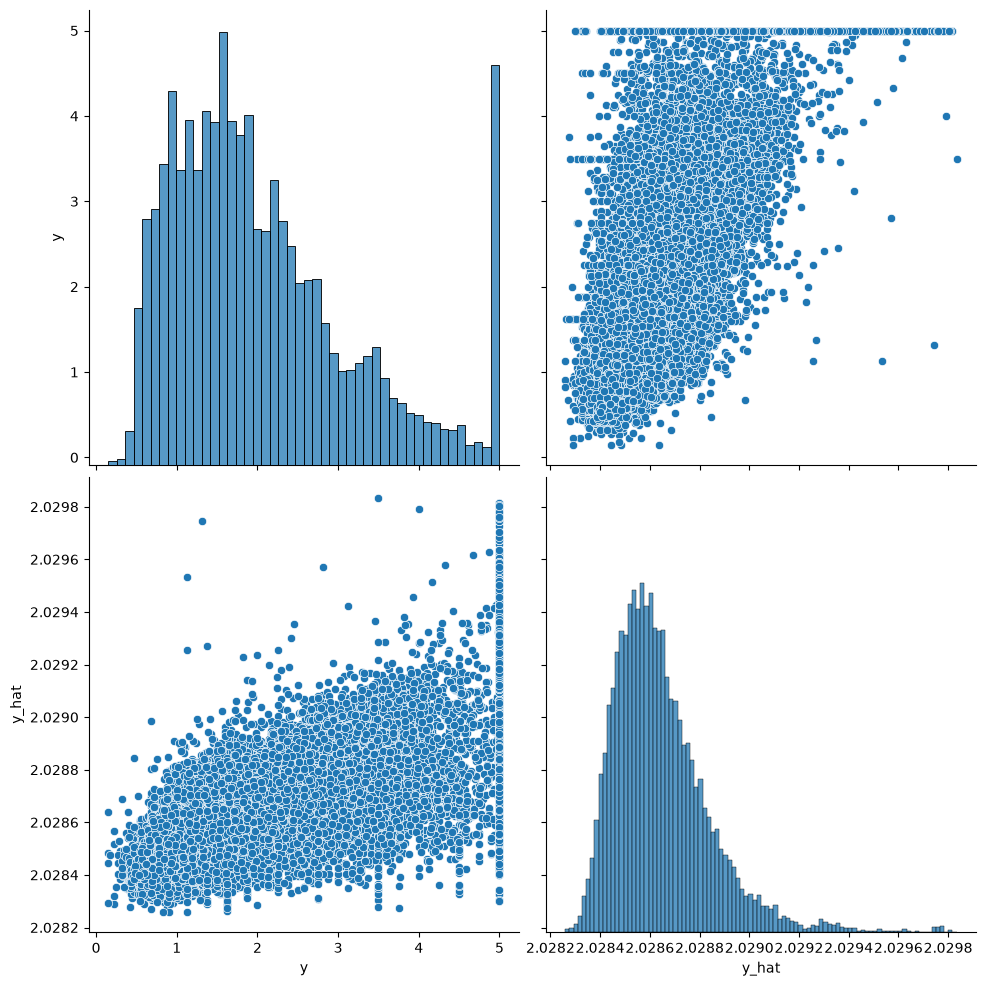

In [ ]:
df = pd.DataFrame(
    torch.cat([y, y_hat], dim= 1).detach_().numpy(),   
    columns= ["y", "y_hat"]
    )

sns.pairplot(df, height= 5)